In [1]:
from src.analyse_equations.analyse_equations import add_all_data_error, print_units_of_one_equation
from src.analyse_equations.analyse_equations import set_pandas_options, create_error_table
from src.analyse_equations.analyse_equations import add_n_fold_error

from src.analyse_equations.add_information_to_equations import add_proposed_equations

from src.analyse_equations.plot_error_per_system import plot_error_per_system
from src.analyse_equations.plot_predictions_of_one_equation import plot_prediction
from src.analyse_equations.utils import save_proposed_equation, get_data_folds, load_proposed_equations

from src.equation_discovery.config_equations_for_each_dataset import ConfigEquationDiscovery
from src.equation_discovery.evaluate_equation import map_equation_to_syntax_tree

from src.preprocess_data.preprocess_data import prepare_dataset, get_unit_dict
from src.analyse_equations.config_analyse_equations import ConfigPlotBestEquation
from src.preprocess_data.config_load_dataset import ConfigLoadData
from src.SyntaxTree.src.syntax_tree.config_syntax_tree import ConfigSyntaxTree
from src.utils.config_hyperparameter import ConfigHyperparameter
import logging
from src.analyse_equations.create_constant_table import create_constant_table

# Configs

In [2]:
logger = logging.getLogger(__name__)
set_pandas_options()

parser = ConfigHyperparameter.arguments_parser()
parser = ConfigLoadData.arguments_parser(parser)
parser = ConfigEquationDiscovery.arguments_parser(parser)
parser = ConfigPlotBestEquation.arguments_parser(parser)
parser = ConfigSyntaxTree.arguments_parser(parser)
args = parser.parse_args()
args.save_path = args.ROOT_DIR / f'results/{args.save_set_folder}/equation_set_{args.equation_set_id}.json'
args.unit_dict = get_unit_dict(args)
args.unit_dict['y'] = args.unit_dict[args.target]
args.unit_dimension = 5
measurement_error_dic = {
    'drop_length': 0.000042,
    'adv': 0.07696902,
    'rec': 0.03298672,
    'avg_vel': 0.0021,
    'width': 0.00005,
    'y_center':0.000003,
    'middle_angle': 0.03141593,
    'x_center': 0.0000042,
    'static_adv': 0.01570796,
    'static_rec': 0.01570796
}
logging.basicConfig(level=logging.INFO)

# Results to load

In [3]:
proposed_equations = load_proposed_equations(args)
add_proposed_equations(args, proposed_equations)

#files_test, files_train = get_train_test_files(args, proposed_equations)
folds_dict = get_data_folds(args, proposed_equations)
all_files = []
for excel_name, files in folds_dict.items():
    all_files.extend(files)

Load proposed equations from: /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/results/Sajjad_Smoothed/equation_set_ID_error_per_dataset.json
Loading 0/10 results from: results/Sajjad_Smoothed/02_Jun_2025_23:47:32_best_models_NGED.json
Loading 1/10 results from: results/Sajjad/04_Apr_2025_09:07:37_best_models_1c_50_interations.json
Loading 2/10 results from: results/Xiaomei/28_Mär_2025_11:41:26_best_models_1c_50_interations.json
Loading 3/10 results from: results/Xiaomei/28_Mär_2025_12:07:31_best_models_1c_50_interations.json
Loading 4/10 results from: results/Xiaomei/01_Apr_2025_17:12:42_best_models_1c_50_interations.json
Loading 5/10 results from: results/Xiaomei/01_Apr_2025_18:10:55_best_models_1c_50_interations.json
Loading 6/10 results from: results/Xiaomei/01_Apr_2025_20:15:19_best_models_1c_50_interations.json
Loading 7/10 results from: results/Xiaomei/01_Apr_2025_20:45:29_best_models_1c_50_interations.json
Loading 8/10 results from: results/Xiaomei/02_Apr_2025_18:

# Cross Validation

In [4]:
filtered_dfs_test, filtered_dfs_train, tree = add_n_fold_error(args, folds_dict, measurement_error_dic, proposed_equations)
save_proposed_equation(args, folds_dict, proposed_equations)

INFO:src.analyse_equations.analyse_equations:Fold 0
INFO:src.analyse_equations.analyse_equations:Fold 1
INFO:src.analyse_equations.analyse_equations:Fold 2
INFO:src.analyse_equations.analyse_equations:Equations removed cause of Unit Error: 216
INFO:src.analyse_equations.analyse_equations:Equations removed cause of MaxDepthError: 0
INFO:src.analyse_equations.analyse_equations:Equations removed cause of Overflow: 0
INFO:src.analyse_equations.analyse_equations:Equations removed cause of other Error: 25
INFO:src.analyse_equations.analyse_equations:Equations kept : 353


Proposed Equations are saved to: /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/results/Sajjad_Smoothed/equation_set_ID_error_per_dataset.json


# Calculate Error over all data

In [5]:
all_data_dfs = prepare_dataset(args, all_files)
add_all_data_error(all_data_dfs, args, proposed_equations)

# Create error table

In [6]:
num_variables = 1
df_error = create_error_table(args, num_variables, proposed_equations)
df_error

INFO:src.analyse_equations.analyse_equations:table with errors saved @/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/table_with_equations_error.tex
INFO:src.analyse_equations.analyse_equations:table with errors saved @/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/table_with_equations_error_mse.tex


                                                       equation                                                                                                                                        infix fold mean train error fold mean test error train all error error calc. std  rank
174                                  * c  / drop_length width                                                                                                ( c_0 * (  ( drop_length )  /  ( width )  )  )               8.98e-06             8.98e-06              9.00e-06  1.27e-06     0
4               + c * friction_coef * width * viscosity avg_vel                                               ( c_0 +  (  ( friction_coef )  * (  ( width )  * (  ( viscosity )  *  ( avg_vel )  )  )  )  )               9.18e-06             9.18e-06              9.20e-06  8.48e-07     1
68                        / drop_length  * c  * rec y_center                                                                             (  ( 

INFO:src.analyse_equations.analyse_equations:table with errors saved @/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/table_with_equations_err_rel.tex


                                                       equation                                                                                                                                        infix fold mean train err_rel fold mean test err_rel train all error err_rel calc. std  rank
174                                  * c  / drop_length width                                                                                                ( c_0 * (  ( drop_length )  /  ( width )  )  )                 8.94e+03               8.94e+03                8.96e+03  1.27e-06     0
4               + c * friction_coef * width * viscosity avg_vel                                               ( c_0 +  (  ( friction_coef )  * (  ( width )  * (  ( viscosity )  *  ( avg_vel )  )  )  )  )                 9.13e+03               9.13e+03                9.14e+03  8.48e-07     1
10                    * 2  *  ** drop_length 2   + avg_vel c                                                            (  (

,equation,infix,fold mean train err_rel,fold mean test err_rel,train all error err_rel,calc. std,rank
174,* c / drop_length width,( c_0 * ( ( drop_length ) / ( width ) ) ),8.94e+03,8.94e+03,8.96e+03,1.27e-06,0
4,+ c * friction_coef * width * viscosity avg_vel,( c_0 + ( ( friction_coef ) * ( ( width ) * ( ( viscosity ) * ( avg_vel ) ) ) ) ),9.13e+03,9.13e+03,9.14e+03,8.48e-07,1
10,* 2 * ** drop_length 2 + avg_vel c,( ( 2 ) * ( ( drop_length ) ** ( ( 2 ) ) * ( ( avg_vel ) + c_0 ) ) ),9.18e+03,9.18e+03,9.21e+03,1.37e-06,2
68,/ drop_length * c * rec y_center,( ( drop_length ) / ( c_0 * ( ( rec ) * ( y_center ) ) ) ),9.27e+03,9.27e+03,9.32e+03,2.17e-07,3
15,* ** drop_length 2 + c 2,( ( drop_length ) ** ( ( 2 ) ) * ( c_0 + ( 2 ) ) ),9.67e+03,9.67e+03,9.69e+03,1.40e-06,4
14,* 3 * c ** drop_length 2,( ( 3 ) * ( c_0 * ( drop_length ) ** ( ( 2 ) ) ) ),9.67e+03,9.67e+03,9.69e+03,1.39e-06,5
20,* 4 * c ** drop_length 2,( ( 4 ) * ( c_0 * ( drop_length ) ** ( ( 2 ) ) ) ),9.67e+03,9.67e+03,9.69e+03,1.40e-06,6
31,* ** c 2 ** drop_length 2,( c_0 ** ( ( 2 ) ) * ( drop_length ) ** ( ( 2 ) ) ),9.67e+03,9.67e+03,9.69e+03,1.04e-06,7
21,* 2 * ** drop_length 2 + c 1,( ( 2 ) * ( ( drop_length ) ** ( ( 2 ) ) * ( c_0 + ( 1 ) ) ) ),9.67e+03,9.67e+03,9.69e+03,1.40e-06,8
17,* ** drop_length 2 + * 2 c 1,( ( drop_length ) ** ( ( 2 ) ) * ( ( ( 2 ) * c_0 ) + ( 1 ) ) ),9.67e+03,9.67e+03,9.69e+03,1.40e-06,9


# Create constant table

In [7]:
index = 174
create_constant_table(all_data_dfs, args, df_error, index, proposed_equations, logger)

INFO:__main__:table with constants saved @ /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/table_with_constants.tex


# Plot units

In [8]:
index =  174
print_units_of_one_equation(args, df_error, index, proposed_equations)

INFO:src.analyse_equations.analyse_equations:('y', '( c_0 * (  ( drop_length )  /  ( width )  )  ) ')


d: 0  id: 0.0   *	 m^1.0 * s^-2.0 * kg^1.0
d: 1  id: 1.0   	c_0	 m^1.0 * s^-2.0 * kg^1.0
d: 1  id: 512.0 	/	 
d: 2  id: 513.0 		drop_length	 m^1.0
d: 2  id: 768.0 		width	 m^1.0


### Plot predictions

Saving prediction plot to: /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/equations/prediction_( c_0 +  (  ( friction_coef )  * (  ( width )  * (  ( viscosity )  *  ( avg_vel )  )  )  )  ) .pdf


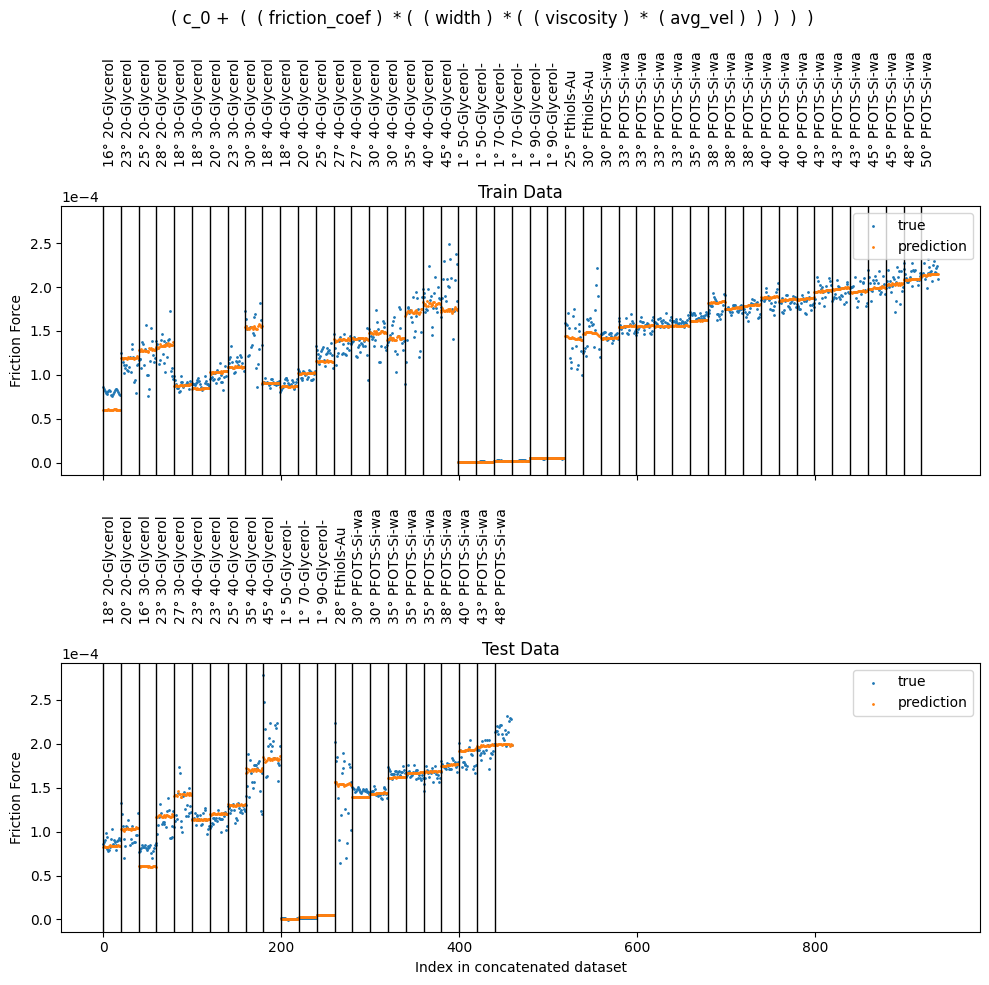

In [12]:
index =  174
equation = proposed_equations[df_error.loc[index].loc['equation']]
tree = map_equation_to_syntax_tree(args, df_error.loc[index].loc['equation'], infix=False, catch_exceptions=False)
tree.constants_in_tree = equation['all_data']['train']['constants']
plot_prediction(args, filtered_dfs_test, filtered_dfs_train, tree)

## Error per system

/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/src/analyse_equations/plot_error_per_system.py:45: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


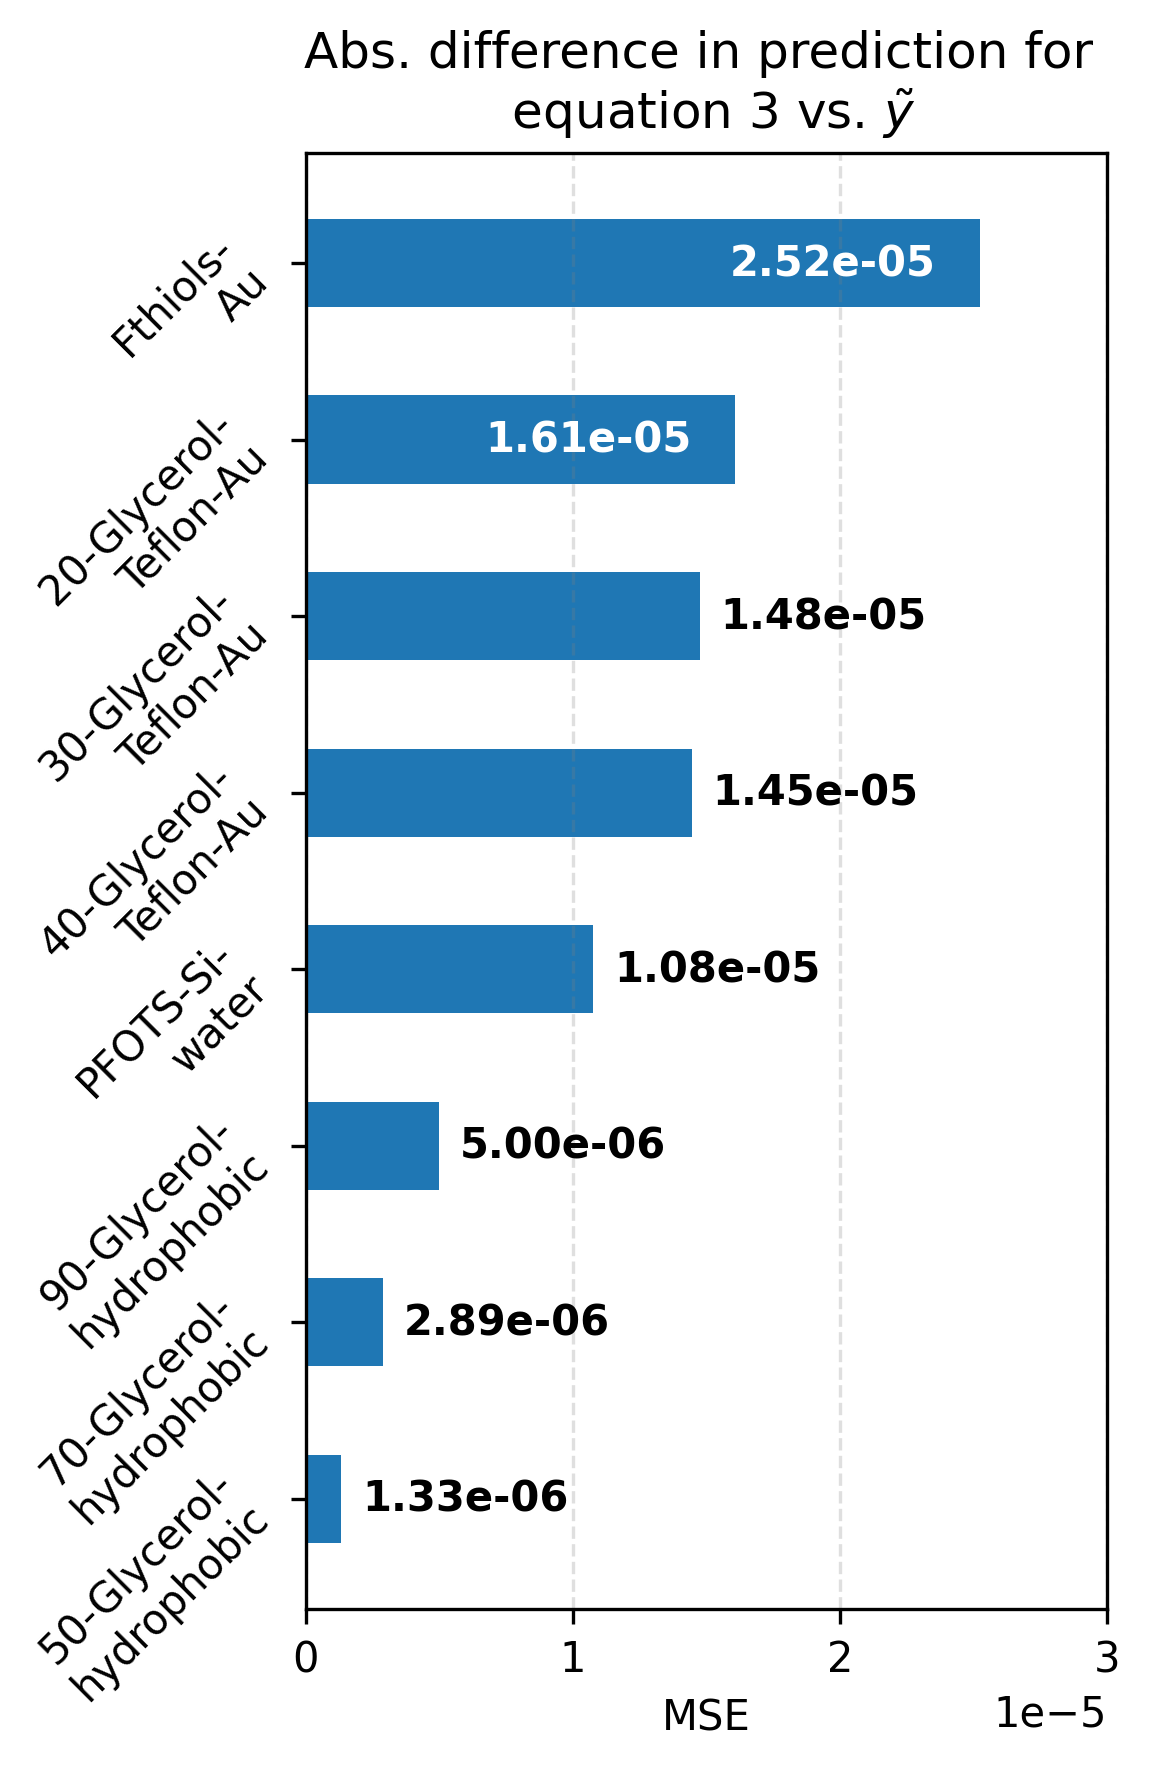

In [10]:
plot_error_per_system(args, df_error, index, proposed_equations)